# Regression Assumptions & Prediction Intervals: Advertising Dataset
## Supuestos de Regresión e Intervalos de Predicción: Dataset Advertising

**Author / Autora:** María Regina Castillo Treviño · [github.com/ReginaPema](https://github.com/ReginaPema)

**Dataset:** `Advertising.csv` — TV, Radio, Newspaper spend vs Sales (200 observations)

**Objective / Objetivo:**  
EN · Build a multiple regression model (TV + Radio + Newspaper → Sales), eliminate non-significant predictors, compute a 90% prediction interval for a new observation, and validate all four regression assumptions (normality, homoscedasticity, independence, linearity) using both library functions and manual formulas.

ES · Construir un modelo de regresión múltiple (TV + Radio + Periódico → Ventas), eliminar predictores no significativos, calcular un intervalo de predicción al 90% para una nueva observación, y validar los cuatro supuestos de regresión usando funciones de librerías y fórmulas manuales.

**Key findings / Hallazgos clave:**  
- `Newspaper` eliminated (p≈0.839). Final model: Sales = 4.639 + 0.055·TV + 0.102·Radio  
- R²=0.899 (train), 0.907 (test); excellent generalization  
- For TV=100, Radio=50: predicted Sales≈15.22, 90% PI=[12.34, 18.10]  
- All library results match manual formulas (Jarque-Bera, Durbin-Watson, White test)

**Techniques / Técnicas:** OLS · Variable selection · 90% Prediction interval · Normality (Jarque-Bera) · Homoscedasticity (White) · Independence (Durbin-Watson) · Manual vs library validation  
**Libraries / Librerías:** `pandas` · `numpy` · `statsmodels` · `sklearn` · `scipy` · `matplotlib` · `seaborn`

---

## 1. Carga y exploración de datos

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy import stats
from statsmodels.stats.diagnostic import het_white
from statsmodels.stats.stattools import durbin_watson, jarque_bera
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error


plt.style.use('fivethirtyeight')

df = pd.read_csv('data/Advertising.csv')
print(f"Dimensiones: {df.shape[0]} observaciones, {df.shape[1]} columnas")
df.head()

Dimensiones: 200 observaciones, 4 columnas


,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [4]:
df.describe()

,TV,Radio,Newspaper,Sales
count,200.0000,200.0000,200.0000,200.0000
mean,147.0425,23.2640,30.5540,15.1305
std,85.8542,14.8468,21.7786,5.2839
min,0.7000,0.0000,0.3000,1.6000
25%,74.3750,9.9750,12.7500,11.0000
50%,149.7500,22.9000,25.7500,16.0000
75%,218.8250,36.5250,45.1000,19.0500
max,296.4000,49.6000,114.0000,27.0000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


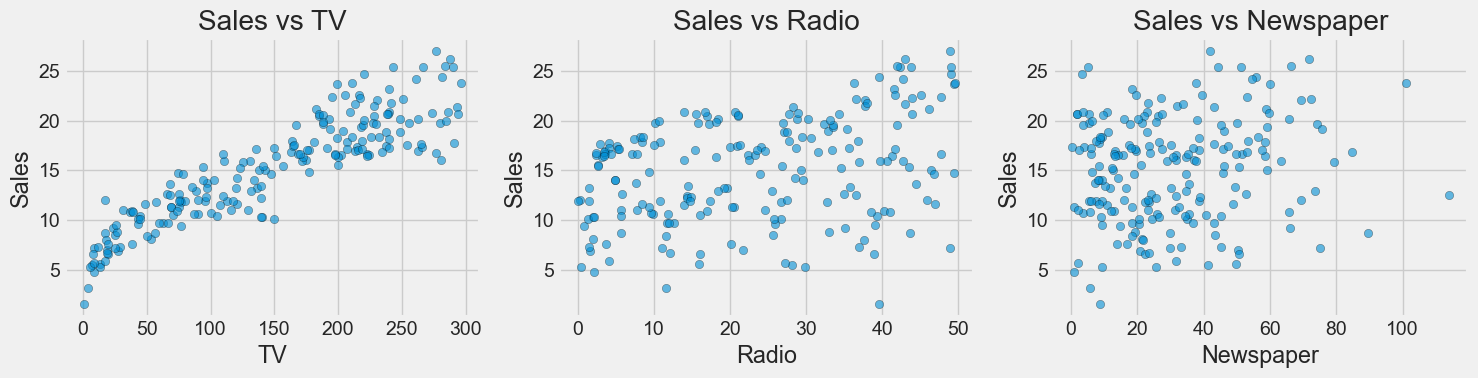


Matriz de correlación:


,TV,Radio,Newspaper,Sales
TV,1.0000,0.0548,0.0566,0.9012
Radio,0.0548,1.0000,0.3541,0.3496
Newspaper,0.0566,0.3541,1.0000,0.1580
Sales,0.9012,0.3496,0.1580,1.0000


In [41]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['TV', 'Radio', 'Newspaper']):
    ax.scatter(df[col], df['Sales'], alpha=0.6, edgecolor='k', linewidth=0.3)
    ax.set_xlabel(col)
    ax.set_ylabel('Sales')
    ax.set_title(f'Sales vs {col}')
plt.tight_layout()
plt.show()

print("\nMatriz de correlación:")
df.corr()

**Lectura rápida:** 
- `TV` muestra una relación lineal fuerte con `Sales` y es el predictor más relevante.
- `Radio` tiene una relación moderada y puede aportar información adicional.
- `Newspaper` presenta una relación débil con Sales y está moderadamente correlacionado con Radio, lo que sugiere que podría no ser significativo en un modelo múltiple.

## 2. División entrenamiento / prueba (70% / 30%, semilla = 1)

In [11]:
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=1)

print(f"Entrenamiento: {X_train.shape[0]} observaciones")
print(f"Prueba: {X_test.shape[0]} observaciones")

Entrenamiento: 140 observaciones
Prueba: 60 observaciones


## 3. Modelo completo y selección de variables significativas

Se ajusta primero el modelo con las tres variables explicativas sobre el conjunto de entrenamiento, y se revisa el valor p de cada coeficiente (nivel de significancia habitual $\alpha = 0.05$) para decidir si debe permanecer en la ecuación final.

In [12]:
X_train_full = sm.add_constant(X_train)
modelo_completo = sm.OLS(y_train, X_train_full).fit()
print(modelo_completo.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.899
Model:                            OLS   Adj. R-squared:                  0.897
Method:                 Least Squares   F-statistic:                     405.2
Date:                Mon, 20 Jul 2026   Prob (F-statistic):           1.36e-67
Time:                        15:13:00   Log-Likelihood:                -272.35
No. Observations:                 140   AIC:                             552.7
Df Residuals:                     136   BIC:                             564.5
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.6614      0.368     12.650      0.0

**Interpretación:** con $\alpha=0.05$, `TV` (p ≈ 0.000) y `Radio` (p ≈ 0.000) son altamente significativas. `Newspaper` tiene un valor p ≈ 0.839, muy por encima de 0.05, por lo que no aporta información significativa para explicar `Sales` una vez que `TV` y `Radio` ya están en el modelo. Se elimina `Newspaper` y se reajusta el modelo con las dos variables restantes (eliminación hacia atrás / backward elimination de un solo paso, suficiente aquí porque solo hay una variable no significativa).

In [13]:
X_train_final = sm.add_constant(X_train[['TV', 'Radio']])
modelo_final = sm.OLS(y_train, X_train_final).fit()
print(modelo_final.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.899
Model:                            OLS   Adj. R-squared:                  0.898
Method:                 Least Squares   F-statistic:                     612.0
Date:                Mon, 20 Jul 2026   Prob (F-statistic):           4.95e-69
Time:                        15:24:12   Log-Likelihood:                -272.37
No. Observations:                 140   AIC:                             550.7
Df Residuals:                     137   BIC:                             559.6
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.6390      0.350     13.240      0.0

**Ecuación final del modelo (datos de entrenamiento):**

$$\widehat{Sales} = 4.639 + 0.0550 \cdot TV + 0.1016 \cdot Radio$$

Ambos coeficientes son significativos (p < 0.001) y tienen signo positivo coherente con la
intuición: más inversión en TV o en Radio se asocia con más ventas.

## 4. Evaluación del ajuste del modelo

Se compara el desempeño del modelo final tanto en el conjunto de entrenamiento (con el que fue ajustado) como en el conjunto de prueba (datos que el modelo no vio), para saber si generaliza bien.

In [15]:
# Desempeño en entrenamiento
r2_train = modelo_final.rsquared
r2_train_adj = modelo_final.rsquared_adj
rmse_train = np.sqrt(modelo_final.mse_resid)

# Desempeño en prueba
X_test_final = sm.add_constant(X_test[['TV', 'Radio']])
y_pred_test = modelo_final.predict(X_test_final)
r2_test = r2_score(y_test, y_pred_test)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))

resumen_ajuste = pd.DataFrame({
    'R²': [r2_train, r2_test],
    'R² ajustada': [r2_train_adj, np.nan],
    'RMSE': [rmse_train, rmse_test]
}, index=['Entrenamiento', 'Prueba'])
resumen_ajuste

,R²,R² ajustada,RMSE
Entrenamiento,0.8993,0.8979,1.7116
Prueba,0.9074,NaN,1.5377


**Interpretación:**

- R²: explica que el modelo con TV y Radio logra capturar el 89.93% de la variabilidad en Sales en los datos de entrenamiento, y 90.74% en los datos de prueba.

- R² ajustada (0.8979): corrige el R² penalizando por el número de predictores. Solo aplica en entrenamiento, porque ajusta el R² en función del número de variables usadas en el ajuste.

- RMSE: el error cuadrático medio en entrenamiento indica que, en promedio, las predicciones se desvían ~1.71 de las ventas reales. El error en prueba, ~1.54, es menor que en entrenamiento, lo cual es buena señal de que el modelo no está sobreajustado.

## 5. Intervalo de confianza del 90% para una predicción puntual

Se pide el intervalo de confianza al 90% para las ventas cuando la inversión es TV = 100, Radio = 50, Newspaper = 70. Como `Newspaper` no forma parte del modelo final (no resultó significativa), la predicción se realiza únicamente con TV = 100 y Radio = 50; el valor de Newspaper no interviene en la ecuación y por tanto no afecta el resultado.

Es importante distinguir dos tipos de intervalo:

- **Intervalo de confianza para la media de respuesta**: rango donde se espera que esté el valor *promedio* de ventas para ese nivel de inversión.
- **Intervalo de predicción (para una observación individual)**: rango donde se espera esté el valor de ventas de *una empresa en particular* con esa inversión. Es más ancho porque suma la incertidumbre de estimar la media más la variabilidad propia de una observación individual.

Se muestran ambos para comparar.

In [32]:
nuevo_punto = pd.DataFrame({'const': [1], 'TV': [100], 'Radio': [50]})
prediccion = modelo_final.get_prediction(nuevo_punto)
resumen_pred = prediccion.summary_frame(alpha=0.10)  # alpha=0.10 → 90% de confianza
resumen_pred

,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
0,15.2217,0.304,14.7182,15.7251,12.3428,18.1005


**Interpretación:**

- mean (15.22) → Predicción puntual del modelo: con TV=100 y Radio=50, las ventas esperadas son ~15.2.

- mean_se (0.304) → Error estándar de la predicción de la media. Cuanto más pequeño, más precisa la estimación.

- mean_ci_lower / mean_ci_upper (14.72 - 15.73) → Intervalo de confianza al 90% para la media poblacional. Si se repitiera este escenario muchas veces, el promedio de ventas estaría en ese rango, que es más estrecho porque no incorpora la variabilidad individual entre observaciones.

- obs_ci_lower / obs_ci_upper (12.34 - 18.10) → Intervalo de predicción al 90% para una observación individual. Es más amplio porque incluye la variabilidad natural de los datos.

In [79]:
# Resumen de predicción
media_est = resumen_pred['mean'].iloc[0]
ic_media = (resumen_pred['mean_ci_lower'].iloc[0], resumen_pred['mean_ci_upper'].iloc[0])
ic_pred = (resumen_pred['obs_ci_lower'].iloc[0], resumen_pred['obs_ci_upper'].iloc[0])

print(f"• Venta puntual estimada: {media_est:.4f}")
print(f"• IC 90% para la media de ventas: [{ic_media[0]:.4f}, {ic_media[1]:.4f}]")
print(f"• Intervalo de predicción 90% (individual): [{ic_pred[0]:.4f}, {ic_pred[1]:.4f}]")

• Venta puntual estimada: 15.2217
• IC 90% para la media de ventas: [14.7182, 15.7251]
• Intervalo de predicción 90% (individual): [12.3428, 18.1005]


## 6. Validación de supuestos del modelo final

Los residuos del modelo ajustado con los datos de entrenamiento son la base para validar los supuestos clásicos de la regresión lineal: linealidad, independencia, homocedasticidad, normalidad y ausencia de multicolinealidad severa. Se usa un nivel de confianza del 90% ($\alpha = 0.10$) en las pruebas de hipótesis.

In [23]:
residuos = modelo_final.resid
valores_ajustados = modelo_final.fittedvalues
n = len(residuos)
alpha = 0.10

### 6.1 Linealidad

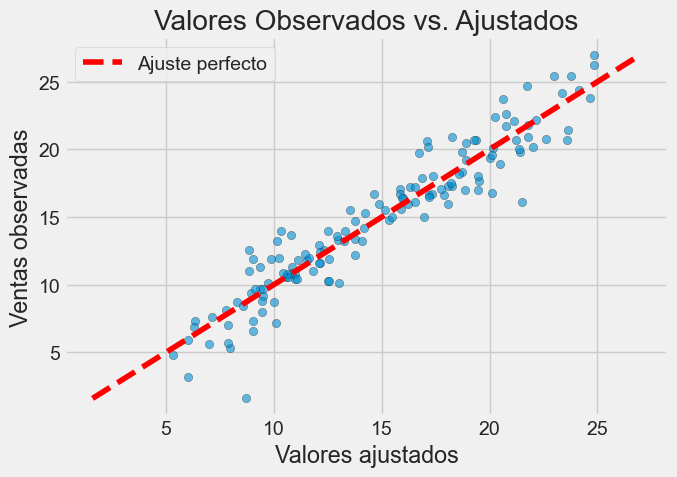

In [43]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(valores_ajustados, y_train, alpha=0.6, edgecolor='k', linewidth=0.3)
lims = [min(y_train.min(), valores_ajustados.min()), max(y_train.max(), valores_ajustados.max())]
ax.plot(lims, lims, 'r--', label='Ajuste perfecto')
ax.set_xlabel('Valores ajustados')
ax.set_ylabel('Ventas observadas')
ax.set_title('Valores Observados vs. Ajustados')
ax.legend()
plt.tight_layout()
plt.show()

**Interpretación:** los puntos se distribuyen de forma razonablemente cercana a la línea de ajuste perfecto, sin una curvatura sistemática evidente. Esto respalda el supuesto de que la relación entre TV, Radio y Sales es adecuadamente capturada por una forma lineal.

### 6.2 Independencia de los errores (estadístico de Durbin-Watson)

In [44]:
dw = durbin_watson(residuos)
print(f"Estadístico de Durbin-Watson: {dw:.4f}")

Estadístico de Durbin-Watson: 2.0375


**Interpretación:** el estadístico de Durbin-Watson oscila entre 0 y 4, con un valor de 2 indicando ausencia de autocorrelación entre residuos consecutivos. El valor obtenido (≈2.04) está prácticamente en 2, por lo que no hay evidencia de autocorrelación en los residuos. Esto es esperable ya que los datos no tienen una estructura temporal o de secuencia.

### 6.3 Homocedasticidad (varianza constante de los residuos): Prueba de White

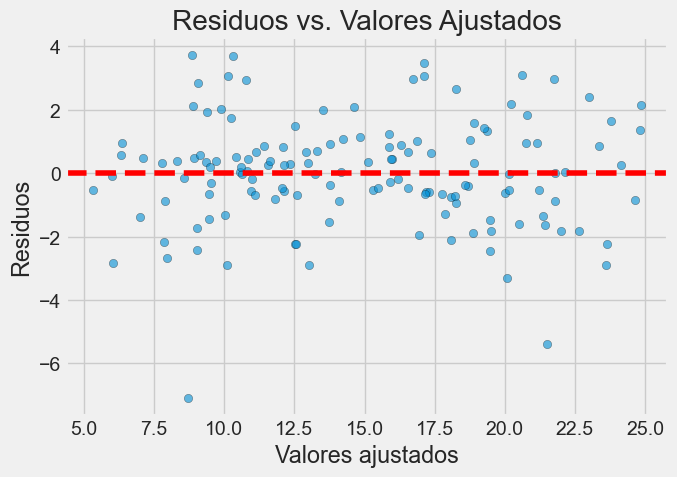

Estadístico LM de White: 11.3534
Valor p (LM): 0.0448


In [46]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(valores_ajustados, residuos, alpha=0.6, edgecolor='k', linewidth=0.3)
ax.axhline(0, color='red', linestyle='--')
ax.set_xlabel('Valores ajustados')
ax.set_ylabel('Residuos')
ax.set_title('Residuos vs. Valores Ajustados')
plt.tight_layout()
plt.show()

white_stat, white_pvalue, white_f, white_f_pvalue = het_white(residuos, X_train_final)
print(f"Estadístico LM de White: {white_stat:.4f}")
print(f"Valor p (LM): {white_pvalue:.4f}")

**Hipótesis de la prueba de White:** $H_0$: varianza de los residuos constante (homocedasticidad) vs. $H_1$: la varianza depende de los regresores (heterocedasticidad).

**Interpretación:** con un valor p ≈ 0.045, que es menor que $\alpha = 0.10$, se rechaza la hipótesis nula de homocedasticidad al 90% de confianza. Es decir, hay evidencia de que la varianza de los errores no es completamente constante. Esto se refleja en la gráfica de residuos donde también se aprecia que la dispersión de los puntos no es perfectamente uniforme a lo largo de todos los valores ajustados. 
Esto no invalida el modelo para fines descriptivos/predictivos generales, pero implica que los errores estándar clásicos (los que usa la regresión OLS, y por tanto los intervalos de confianza y pruebas t) podrían ser ligeramente optimistas. Se podría corregir sin necesidad de cambiar el modelo usando errores estándar robustos (*HC*, heterocedasticidad-consistentes).

### 6.4 Normalidad de los residuos (Sesgo, Curtosis y prueba de Jarque-Bera)

• Sesgo (skewness)         →  -0.5124
• Curtosis de exceso       →  1.7826
• Estadístico Jarque-Bera  →  24.6629
• Valor p (Jarque-Bera)    →  0.000004


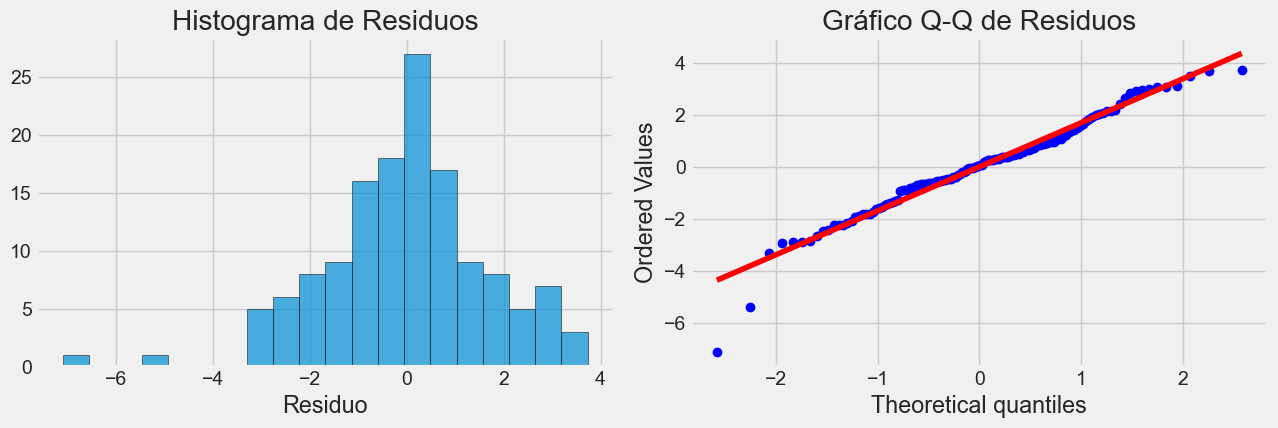

In [51]:
sesgo = stats.skew(residuos)
curtosis_exceso = stats.kurtosis(residuos)  # curtosis de exceso (Fisher); Normal = 0
jb_stat, jb_pvalue, jb_skew, jb_kurt = jarque_bera(residuos)

print(f"• Sesgo (skewness)         →  {sesgo:.4f}")
print(f"• Curtosis de exceso       →  {curtosis_exceso:.4f}")
print(f"• Estadístico Jarque-Bera  →  {jb_stat:.4f}")
print(f"• Valor p (Jarque-Bera)    →  {jb_pvalue:.6f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].hist(residuos, bins=20, edgecolor='k', alpha=0.7)
axes[0].set_title('Histograma de Residuos')
axes[0].set_xlabel('Residuo')

stats.probplot(residuos, dist="norm", plot=axes[1])
axes[1].set_title('Gráfico Q-Q de Residuos')
plt.tight_layout()
plt.show()

**Interpretación:**

- El **sesgo ≈ -0.51** → Asimetría negativa moderada: la distribución de los residuos tiene una cola izquierda más larga. Esto significa que en algunos casos el modelo sobreestima las ventas (residuos negativos grandes).
- La **curtosis de exceso ≈ 1.78** → Distribución **leptocúrtica**: más apuntada y con colas más pesadas que la normal (que tiene curtosis de exceso = 0). Hay más valores extremos de lo esperado bajo normalidad.
- La prueba de **Jarque–Bera** ≈ 24.66 → La hipótesis nula es que los residuos siguen una distribución normal: como el valor p ≈ 0.000004 está muy por debajo de $\alpha = 0.10$, se rechaza la normalidad de los residuos al 90% de confianza, e incluso con niveles de confianza más estrictos (90%, 95%, 99%).
- El histograma: se ve centrado en cero, pero con colas más largas de lo esperado.
- El gráfico Q-Q: los puntos siguen la línea en el centro, pero se separan en las colas confirmando la falta de normalidad.

Los residuos muestran asimetría negativa moderada, colas pesadas y rechazo de normalidad. Esto, junto con la heterocedasticidad ya detectada, sugiere que el fenómeno real puede ser más complejo que un modelo lineal simple, aunque el ajuste sigue útil para fines predictivos.

### 6.5 Ausencia de multicolinealidad severa (Factor de Inflación de la Varianza, VIF)

In [52]:
vif_data = pd.DataFrame()
vif_data['Variable'] = X_train_final.columns[1:]  # excluye la constante
vif_data['VIF'] = [variance_inflation_factor(X_train_final.values, i)
                    for i in range(1, X_train_final.shape[1])]
vif_data

,Variable,VIF
0,TV,1.0014
1,Radio,1.0014


**Interpretación:** como regla práctica, valores de VIF por debajo de 5 (o incluso de 10) indican ausencia de multicolinealidad problemática. Aquí ambos VIF son prácticamente 1, lo que indica que TV y Radio son, para efectos del modelo, variables prácticamente no correlacionadas entre sí. El supuesto de no-multicolinealidad severa se cumple.

### 6.6 Resumen de supuestos

| Supuesto | Método | Resultado | ¿Se cumple? (90% confianza) |
|---|---|---|---|
| Linealidad | Inspección gráfica (observado vs. ajustado) | Relación aproximadamente lineal | Sí |
| Independencia de errores | Durbin-Watson | DW ≈ 2.04 (cercano a 2) | Sí |
| Homocedasticidad | Prueba de White | p ≈ 0.045 < 0.10 | **No** |
| Normalidad de residuos | Sesgo, Curtosis, Jarque-Bera | p ≈ 0.0000044 < 0.10 | **No** |
| No multicolinealidad | VIF | VIF ≈ 1.0 en ambas variables | Sí |

## 7. Verificación manual de supuestos

### 7.1 Sesgo (skewness) y Curtosis manuales

Fórmulas de momentos (con varianza poblacional, que es la convención que usan tanto `scipy.stats.skew`/`kurtosis` por defecto como `statsmodels`):

$$\text{Sesgo} = \frac{\frac{1}{n}\sum_{i=1}^{n}(e_i-\bar{e})^3}{\left(\frac{1}{n}\sum_{i=1}^{n}(e_i-\bar{e})^2\right)^{3/2}}$$

$$\text{Curtosis de exceso} = \frac{\frac{1}{n}\sum_{i=1}^{n}(e_i-\bar{e})^4}{\left(\frac{1}{n}\sum_{i=1}^{n}(e_i-\bar{e})^2\right)^{2}} - 3$$

donde $e_i$ son los residuos y $\bar{e}$ su media (que en OLS con intercepto es, por construcción, prácticamente 0).

In [64]:
def sesgo_manual(e):
    e = np.asarray(e)
    n = len(e)
    media = np.mean(e)
    m2 = np.mean((e - media) ** 2)   # segundo momento (varianza poblacional)
    m3 = np.mean((e - media) ** 3)   # tercer momento
    return m3 / m2 ** 1.5

def curtosis_manual(e):
    e = np.asarray(e)
    media = np.mean(e)
    m2 = np.mean((e - media) ** 2)
    m4 = np.mean((e - media) ** 4)
    return m4 / m2 ** 2 - 3   # curtosis de exceso (Normal = 0)

sesgo_prop = sesgo_manual(residuos)
curtosis_prop = curtosis_manual(residuos)

print("             Sesgo       Curtosis (exceso)")
print(f"Librería    {sesgo:.6f}    {curtosis_exceso:.6f}")
print(f"Manual      {sesgo_prop:.6f}    {curtosis_prop:.6f}")
print(f"Diferencia   {abs(sesgo - sesgo_prop):.2e}    {abs(curtosis_exceso - curtosis_prop):.2e}")

             Sesgo       Curtosis (exceso)
Librería    -0.512418    1.782591
Manual      -0.512418    1.782591
Diferencia   0.00e+00    1.78e-15


Los valores manuales coinciden con los que entrega `scipy.stats`. Con estos mismos momentos se puede reconstruir el estadístico de Jarque–Bera:

$$JB = \frac{n}{6}\left(\text{Sesgo}^2 + \frac{\text{Curtosis de exceso}^2}{4}\right)$$

In [65]:
jb_manual = n / 6 * (sesgo_prop ** 2 + curtosis_prop ** 2 / 4)
jb_pvalue_manual = 1 - stats.chi2.cdf(jb_manual, df=2)  # JB se distribuye chi-cuadrada con 2 g.l.

print(f"JB (librería) = {jb_stat:.6f}   p = {jb_pvalue:.8f}")
print(f"JB (manual)   = {jb_manual:.6f}   p = {jb_pvalue_manual:.8f}")

JB (librería) = 24.662861   p = 0.00000441
JB (manual)   = 24.662861   p = 0.00000441


### 7.2 Estadístico de Durbin-Watson manual

$$DW = \frac{\sum_{i=2}^{n}(e_i - e_{i-1})^2}{\sum_{i=1}^{n}e_i^2}$$

In [73]:
def durbin_watson_manual(e):
    e = np.asarray(e)
    numerador = np.sum(np.diff(e) ** 2)
    denominador = np.sum(e ** 2)
    return numerador / denominador

dw_prop = durbin_watson_manual(residuos)
print(f"DW (librería): {dw:.6f}")
print(f"DW (manual):   {dw_prop:.6f}")
print(f"Diferencia:    {abs(dw - dw_prop):.2e}")

DW (librería): 2.037516
DW (manual):   2.037516
Diferencia:    0.00e+00


El valor calculado manualmente coincide exactamente con el que entrega `statsmodels.stats.stattools.durbin_watson`

### 7.3 Prueba de heterocedasticidad de White manual

El procedimiento de White consiste en:

1. Obtener los residuos $e_i$ del modelo original y elevarlos al cuadrado ($e_i^2$).
2. Ajustar una regresión auxiliar de $e_i^2$ sobre los regresores originales, sus cuadrados y sus productos cruzados (aquí: TV, Radio, TV², Radio², TV·Radio).
3. Calcular el estadístico $LM = n \cdot R^2_{aux}$, donde $R^2_{aux}$ es la $R^2$ de esa regresión auxiliar.
4. Bajo $H_0$ (homocedasticidad), $LM$ se distribuye aproximadamente como una $\chi^2$ con grados de libertad iguales al número de regresores de la ecuación auxiliar (sin contar la constante).

In [71]:
def white_test_manual(residuos, X_con_const):
    # Replica la prueba de White (statsmodels.stats.diagnostic.het_white)
    e2 = pd.Series(np.asarray(residuos) ** 2, index=X_con_const.index)

    regresores = X_con_const.drop(columns='const')
    aux = regresores.copy()
    # Términos cuadráticos
    for col in regresores.columns:
        aux[f'{col}^2'] = regresores[col] ** 2
    # Productos cruzados
    cols = list(regresores.columns)
    for i in range(len(cols)):
        for j in range(i + 1, len(cols)):
            aux[f'{cols[i]}*{cols[j]}'] = regresores[cols[i]] * regresores[cols[j]]

    aux_const = sm.add_constant(aux)
    modelo_aux = sm.OLS(e2, aux_const).fit()

    n_local = len(e2)
    k = aux_const.shape[1] - 1  # regresores sin la constante
    LM = n_local * modelo_aux.rsquared
    p_LM = 1 - stats.chi2.cdf(LM, df=k)
    return LM, p_LM, k

LM_manual, p_LM_manual, gl = white_test_manual(residuos, X_train_final)

print(f"White (librería): LM = {white_stat:.6f}   p = {white_pvalue:.6f}")
print(f"White (manual):   LM = {LM_manual:.6f}   p = {p_LM_manual:.6f}   (g.l. = {gl})")
print(f"Diferencia LM: {abs(white_stat - LM_manual):.2e}")

White (librería): LM = 11.353378   p = 0.044807
White (manual):   LM = 11.353378   p = 0.044807   (g.l. = 5)
Diferencia LM: 0.00e+00


El estadístico LM y su valor p calculados manualmente coinciden con los de `statsmodels.stats.diagnostic.het_white`.

In [76]:
### 7.4 Tabla comparativa final entre los cinco estadísticos calculados por la libreria vs manualmente

In [78]:
tabla_comparativa = pd.DataFrame({
    'Estadístico': ['Sesgo', 'Curtosis (exceso)', 'Jarque-Bera', 'Durbin-Watson', 'White (LM)'],
    'Librería': [sesgo, curtosis_exceso, jb_stat, dw, white_stat],
    'Manual': [sesgo_prop, curtosis_prop, jb_manual, dw_prop, LM_manual],
})
tabla_comparativa['Diferencia absoluta'] = (tabla_comparativa['Librería'] - tabla_comparativa['Manual']).abs()
tabla_comparativa

,Estadístico,Librería,Manual,Diferencia absoluta
0,Sesgo,-0.5124,-0.5124,0.0000e+00
1,Curtosis (exceso),1.7826,1.7826,1.7764e-15
2,Jarque-Bera,24.6629,24.6629,3.9080e-14
3,Durbin-Watson,2.0375,2.0375,0.0000e+00
4,White (LM),11.3534,11.3534,0.0000e+00


## 8. Conclusiones

- El modelo final de regresión lineal múltiple queda expresado como $\widehat{Sales} = 4.639 + 0.0550\cdot TV + 0.1016\cdot Radio$, tras eliminar `Newspaper` por no ser estadísticamente significativa (p ≈ 0.839).
- El ajuste es muy bueno: $R^2 \approx 0.899$ en entrenamiento y $\approx 0.907$ en prueba, con errores de predicción (RMSE) consistentes entre ambos conjuntos (~1.5), lo que indica que el modelo generaliza bien y no está sobreajustado.
- Para una inversión de TV = 100 y Radio = 50 (Newspaper no interviene en el modelo final), la venta puntual esperada es de ≈ 15.22, con un intervalo de predicción del 90% de [12.34, 18.10] para una observación individual, y un intervalo de confianza del 90% de [14.72, 15.73] para el promedio de ventas.
- De los cinco supuestos revisados, tres se cumplen: linealidad, independencia de errores y ausencia de multicolinealidad; mientras que dos se incumplen al 90% de confianza: hay evidencia de heterocedasticidad (prueba de White, p ≈ 0.045) y de no normalidad de los residuos (Jarque-Bera, p ≈ 0.0000044), con sesgo negativo y colas más pesadas que las de una normal. Esto sugiere que, más allá del modelo lineal aditivo, podría existir algo de curvatura o interacción entre TV y Radio (rendimientos decrecientes de la inversión publicitaria) que valdría la pena explorar en una siguiente iteración (por ejemplo, agregando un término de interacción TV×Radio o transformaciones no lineales).
- La verificación manual de Sesgo, Curtosis, Durbin-Watson y la prueba de White, implementadas mediante funciones propias a partir de las fórmulas de la lección, reproduce casi exactamente los resultados entregados por `scipy.stats` y `statsmodels`, confirmando la correcta comprensión matemática detrás de cada estadístico.